# Lab 7: Global Superstore Sales Dashboard using Plotly

## Imports

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from plotly.subplots import make_subplots
from IPython.display import display, clear_output

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Clean the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('datasets/Global_Superstore2.csv', encoding='latin-1')

# Column name cleanup
df.columns = df.columns.str.strip()

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

# Drop rows with missing critical fields
df.dropna(subset=['Order Date', 'Sales', 'Profit', 'Category'], inplace=True)

# Derived columns
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')
df['YearMonth']  = df['Order Date'].dt.to_period('M').astype(str)

df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year,Month,Month Name,YearMonth
0,32298,CA-2012-124891,2012-07-31,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,2309.650,7,0.0,762.1845,933.57,Critical,2012,7,Jul,2012-07
1,26341,IN-2013-77878,2013-02-05,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,3709.395,9,0.1,-288.7650,923.63,Critical,2013,2,Feb,2013-02
2,25330,IN-2013-71249,2013-10-17,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,5175.171,9,0.1,919.9710,915.49,Medium,2013,10,Oct,2013-10


In [3]:
print(f'Rows: {len(df):,}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')

Rows: 51,290
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority', 'Year', 'Month', 'Month Name', 'YearMonth']
Date range: 2011-01-01 to 2014-12-31


## 2. EDA

In [4]:
print('=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\n=== Unique Values ===')
for col in ['Category', 'Segment', 'Ship Mode', 'Region']:
    if col in df.columns:
        print(f'{col}: {df[col].unique().tolist()}')

print('\n=== Summary Statistics ===')
display(df[['Sales', 'Profit', 'Quantity', 'Discount']].describe().round(2))

=== Missing Values ===
Postal Code    41296
dtype: int64

=== Unique Values ===
Category: ['Technology', 'Furniture', 'Office Supplies']
Segment: ['Consumer', 'Corporate', 'Home Office']
Ship Mode: ['Same Day', 'Second Class', 'First Class', 'Standard Class']
Region: ['East', 'Oceania', 'Central', 'Africa', 'West', 'South', 'Central Asia', 'EMEA', 'North Asia', 'North', 'Caribbean', 'Southeast Asia', 'Canada']

=== Summary Statistics ===


,Sales,Profit,Quantity,Discount
count,51290.00,51290.00,51290.00,51290.00
mean,246.49,28.61,3.48,0.14
std,487.57,174.34,2.28,0.21
min,0.44,-6599.98,1.00,0.00
25%,30.76,0.00,2.00,0.00
50%,85.05,9.24,3.00,0.00
75%,251.05,36.81,5.00,0.20
max,22638.48,8399.98,14.00,0.85


## 3. Chart Helper Functions

Each function takes a filtered dataframe and returns a Plotly figure.

In [5]:
# Shared theme settings applied to every chart
TEMPLATE   = 'plotly_white'
CAT_COLORS = {'Technology': '#4F46E5', 'Furniture': '#F59E0B', 'Office Supplies': '#10B981'}
SEQ_COLORS = ['#4F46E5', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def apply_theme(fig, height=380):
    fig.update_layout(
        template=TEMPLATE,
        height=height,
        margin=dict(l=50, r=30, t=60, b=50),
        font=dict(family='Arial, sans-serif', size=12, color='#1E293B'),
        paper_bgcolor='white',
        plot_bgcolor='#F8FAFC',
        title_font=dict(size=15, color='#0F172A', family='Arial, sans-serif', weight=700),
        title_x=0.5,
        xaxis=dict(
            title_font=dict(size=12, color='#475569'),
            tickfont=dict(size=11, color='#475569'),
            gridcolor='#E2E8F0',
            linecolor='#CBD5E1',
            showline=True,
        ),
        yaxis=dict(
            title_font=dict(size=12, color='#475569'),
            tickfont=dict(size=11, color='#475569'),
            gridcolor='#E2E8F0',
            linecolor='#CBD5E1',
            showline=True,
        ),
        legend=dict(
            font=dict(size=11, color='#334155'),
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='#E2E8F0',
            borderwidth=1,
        ),
        hoverlabel=dict(
            bgcolor='#1E293B',
            font_size=12,
            font_color='white',
            bordercolor='#1E293B',
        ),
    )
    return fig


# 1. KPI Summary
def show_kpi(fdf):
    total_sales  = fdf['Sales'].sum()
    total_profit = fdf['Profit'].sum()
    total_orders = fdf['Order ID'].nunique() if 'Order ID' in fdf.columns else len(fdf)
    margin       = (total_profit / total_sales * 100) if total_sales else 0
    avg_discount = fdf['Discount'].mean() * 100 if 'Discount' in fdf.columns else 0

    cards = [
        ('Total Revenue',   f'${total_sales:,.0f}',  '#4F46E5'),
        ('Net Profit',      f'${total_profit:,.0f}', '#10B981'),
        ('Total Orders',    f'{total_orders:,}',     '#F59E0B'),
        ('Profit Margin',   f'{margin:.1f}%',        '#EF4444'),
        ('Avg Discount',    f'{avg_discount:.1f}%',  '#8B5CF6'),
    ]
    card_html = ''.join([
        f'''<div style="flex:1; background:white; border:1px solid #E2E8F0;
                        border-radius:10px; padding:16px 20px; text-align:center;
                        border-top:3px solid {color}; min-width:140px; 
                        font-weight: 900;">  <!-- Set to 900 for maximum darkness -->
                <div style="font-size:11px; color:#1A202C; text-transform:uppercase;
                                letter-spacing:0.06em; margin-bottom:6px;">{label}</div>
                <div style="font-size:22px; color:{color};">{value}</div>
            </div>'''

        for label, value, color in cards
    ])
    html_widget = widgets.HTML(
        value=f'<div style="display:flex; gap:14px; padding:10px 0; flex-wrap:wrap;">{card_html}</div>'
    )
    display(html_widget)


# 2. Monthly Revenue and Profit Trend
def fig_trend(fdf):
    monthly = (
        fdf.groupby('YearMonth')
        .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
        .reset_index()
        .sort_values('YearMonth')
    )
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=monthly['YearMonth'], y=monthly['Sales'].round(0),
        name='Sales', mode='lines',
        line=dict(color='#4F46E5', width=2.5),
        fill='tozeroy', fillcolor='rgba(79,70,229,0.08)',
        hovertemplate='%{x}<br>Sales: $%{y:,.0f}<extra></extra>'
    ))
    fig.add_trace(go.Scatter(
        x=monthly['YearMonth'], y=monthly['Profit'].round(0),
        name='Profit', mode='lines',
        line=dict(color='#10B981', width=2, dash='dot'),
        hovertemplate='%{x}<br>Profit: $%{y:,.0f}<extra></extra>'
    ))
    fig.update_layout(
        title=dict(text='<b>Monthly Revenue and Profit Trend</b>', x=0.5, xanchor='center'),
        xaxis_title='Month', yaxis_title='Amount (USD)',
        hovermode='x unified', legend=dict(orientation='h', y=-0.25, x=0.5, xanchor='center')
    )
    return apply_theme(fig)


# 3. Sales by Region - Donut
def fig_region_donut(fdf):
    reg = fdf.groupby('Region')['Sales'].sum().reset_index()
    fig = go.Figure(go.Pie(
        labels=reg['Region'],
        values=reg['Sales'].round(0),
        hole=0.55,
        textinfo='percent+label',
        marker=dict(colors=SEQ_COLORS,
                    line=dict(color='white', width=2)),
        hovertemplate='%{label}<br>Sales: $%{value:,.0f}<br>Share: %{percent}<extra></extra>'
    ))
    fig.update_layout(title=dict(text='<b>Sales by Region</b>', x=0.5, xanchor='center'), showlegend=False)
    return apply_theme(fig)


# 4. Sales by Sub-Category - Horizontal Bar
def fig_subcat_bar(fdf):
    sc = (
        fdf.groupby(['Category', 'Sub-Category'])['Sales']
        .sum().reset_index()
        .sort_values('Sales')
    )
    fig = px.bar(
        sc, x='Sales', y='Sub-Category', color='Category',
        orientation='h',
        color_discrete_map=CAT_COLORS,
        text=sc['Sales'].apply(lambda v: f'${v/1000:.0f}K'),
    )
    fig.update_traces(textposition='outside', hovertemplate='%{y}<br>Sales: $%{x:,.0f}<extra></extra>')
    fig.update_layout(
        title=dict(text='<b>Sales by Sub-Category</b>', x=0.5, xanchor='center'),
        xaxis_title='Sales (USD)', yaxis_title='',
        legend=dict(orientation='h', y=-0.18, x=0.5, xanchor='center')
    )
    return apply_theme(fig, height=420)


# 5. Heatmap - Category x Month
def fig_heatmap(fdf):
    hd = fdf.groupby(['Category', 'Month Name'])['Sales'].sum().reset_index()
    months_present = [m for m in MONTH_ORDER if m in hd['Month Name'].values]
    hp = (
        hd.pivot(index='Category', columns='Month Name', values='Sales')
        .reindex(columns=months_present)
        .fillna(0)
        .round(0)
    )
    fig = px.imshow(
        hp,
        text_auto='.2s',
        color_continuous_scale=[[0, '#EEF2FF'], [0.5, '#6366F1'], [1, '#312E81']],
        aspect='auto'
    )
    fig.update_traces(hovertemplate='Category: %{y}<br>Month: %{x}<br>Sales: $%{z:,.0f}<extra></extra>')
    fig.update_layout(
        title=dict(text='<b>Sales Heatmap - Category x Month</b>', x=0.5, xanchor='center'),
        xaxis_title='Month', yaxis_title='',
        coloraxis_showscale=False
    )
    return apply_theme(fig, height=260)


# 6. Top 10 Countries
def fig_top_countries(fdf):
    co = (
        fdf.groupby('Country')['Sales'].sum()
        .nlargest(10).reset_index()
        .sort_values('Sales')
    )
    fig = go.Figure(go.Bar(
        x=co['Sales'].round(0),
        y=co['Country'],
        orientation='h',
        marker=dict(
            color=co['Sales'],
            colorscale=[[0, '#C7D2FE'], [1, '#3730A3']],
            line=dict(width=0)
        ),
        text=co['Sales'].apply(lambda v: f'${v/1000:.0f}K'),
        textposition='outside',
        hovertemplate='%{y}<br>Sales: $%{x:,.0f}<extra></extra>'
    ))
    fig.update_layout(title=dict(text='<b>Top 10 Countries by Sales</b>', x=0.5, xanchor='center'), xaxis_title='Sales (USD)', yaxis_title='')
    return apply_theme(fig)


# 7. Profit Margin by Segment and Category
def fig_margin(fdf):
    mg = (
        fdf.groupby(['Segment', 'Category'])
        .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
        .reset_index()
    )
    mg['Margin%'] = (mg['Profit'] / mg['Sales'] * 100).round(1)
    fig = px.bar(
        mg, x='Segment', y='Margin%', color='Category',
        barmode='group',
        color_discrete_map=CAT_COLORS,
        text=mg['Margin%'].apply(lambda v: f'{v:.1f}%'),
    )
    fig.update_traces(textposition='outside', hovertemplate='%{x} — %{fullData.name}<br>Margin: %{y:.1f}%<extra></extra>')
    fig.add_hline(y=0, line_color='#EF4444', line_dash='dash', line_width=1.2)
    fig.update_layout(
        title=dict(text='<b>Profit Margin % by Segment and Category</b>', x=0.5, xanchor='center'),
        yaxis_title='Margin (%)', xaxis_title='',
        legend=dict(orientation='h', y=-0.25, x=0.5, xanchor='center')
    )
    return apply_theme(fig)


# 8. Ship Mode Distribution
def fig_ship_mode(fdf):
    sh = fdf.groupby('Ship Mode')['Sales'].sum().reset_index()
    fig = go.Figure(go.Pie(
        labels=sh['Ship Mode'],
        values=sh['Sales'].round(0),
        textinfo='percent+label',
        marker=dict(colors=SEQ_COLORS,
                    line=dict(color='white', width=2)),
        hovertemplate='%{label}<br>Sales: $%{value:,.0f}<extra></extra>'
    ))
    fig.update_layout(title=dict(text='<b>Sales by Ship Mode</b>', x=0.5, xanchor='center'), showlegend=False)
    return apply_theme(fig)


# 9. Choropleth Map
def fig_map(fdf):
    c2 = fdf.groupby('Country')['Sales'].sum().reset_index().round(0)
    fig = px.choropleth(
        c2,
        locations='Country',
        locationmode='country names',
        color='Sales',
        color_continuous_scale=[[0, '#EEF2FF'], [0.4, '#6366F1'], [1, '#1E1B4B']],
        hover_name='Country',
        hover_data={'Sales': ':,.0f'},
    )
    fig.update_layout(
        title=dict(text='<b>Global Sales Distribution</b>', x=0.5, xanchor='center'),
        geo=dict(showframe=False, showcoastlines=True,
                 coastlinecolor='#CBD5E1', landcolor='#F1F5F9',
                 oceancolor='#EFF6FF', showocean=True,
                 bgcolor='white'),
        coloraxis_colorbar=dict(title='Sales (USD)', tickprefix='$'),
        margin=dict(l=0, r=0, t=45, b=0)
    )
    fig.update_layout(template=TEMPLATE, height=420, paper_bgcolor='white')
    return fig

## 4. Individual Chart Previews (no filters)

In [6]:
show_kpi(df)

HTML(value='<div style="display:flex; gap:14px; padding:10px 0; flex-wrap:wrap;"><div style="flex:1; backgroun…

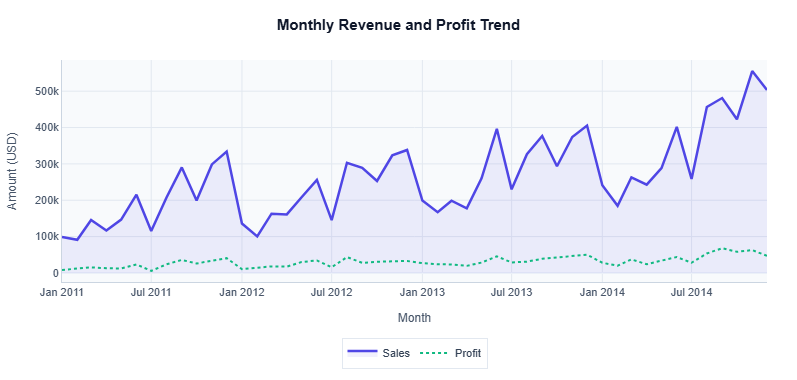

In [7]:
fig_trend(df).show()

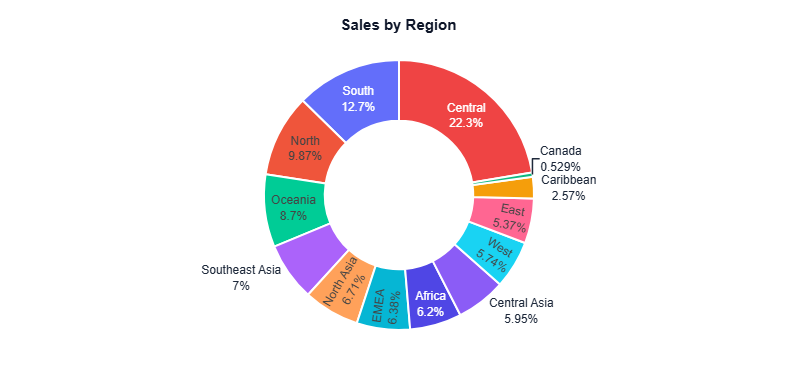

In [8]:
fig_region_donut(df).show()

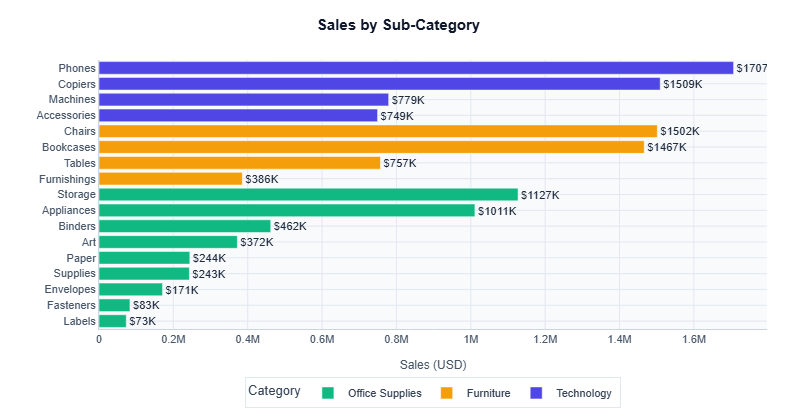

In [9]:
fig_subcat_bar(df).show()

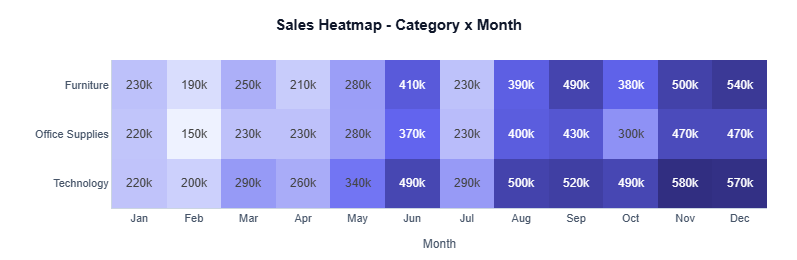

In [10]:
fig_heatmap(df).show()

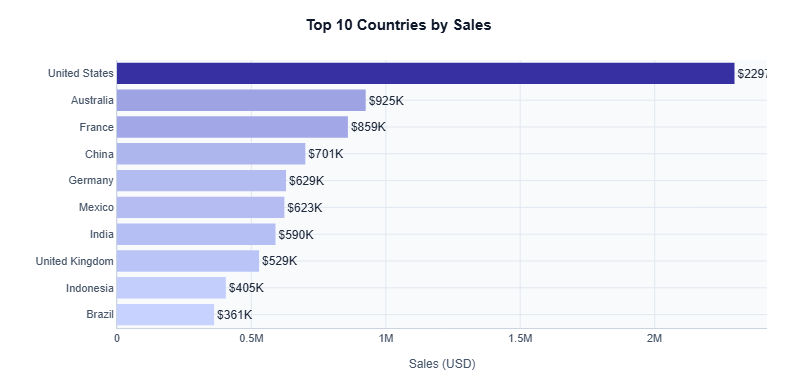

In [11]:
fig_top_countries(df).show()

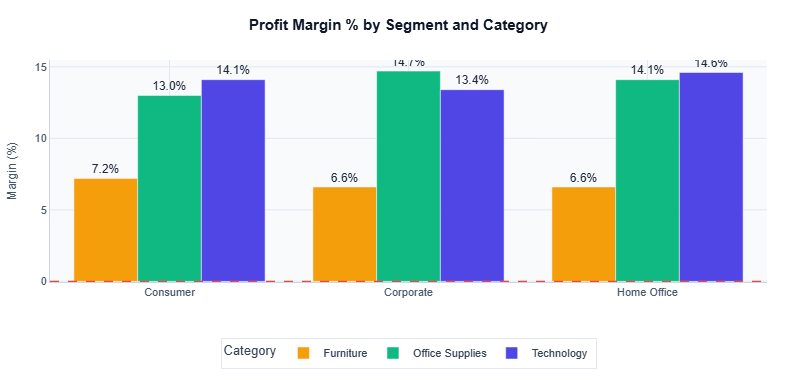

In [12]:
fig_margin(df).show()

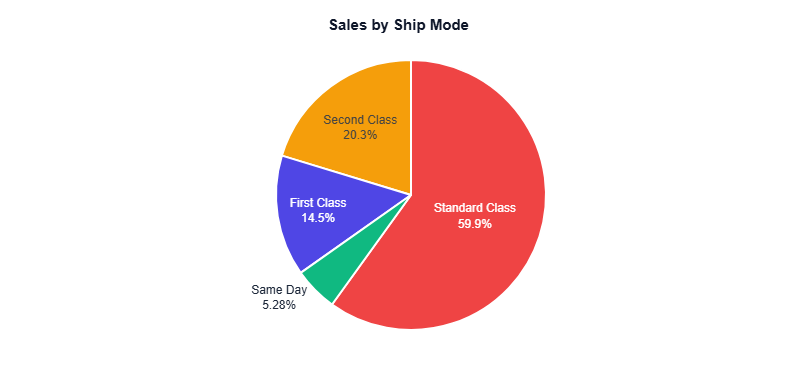

In [13]:
fig_ship_mode(df).show()

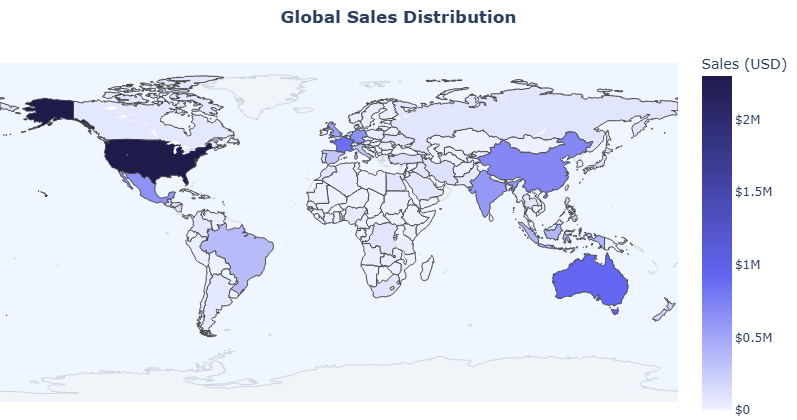

In [14]:
fig_map(df).show()

## 5. Interactive Dashboard

Three dropdown filters (Year, Segment, Category) control all charts simultaneously. Selecting any filter re-renders the entire dashboard on the filtered subset of the data.

In [15]:
# Filter options
year_opts = ['All'] + sorted(df['Year'].dropna().unique().astype(int).tolist())
seg_opts  = ['All'] + sorted(df['Segment'].dropna().unique().tolist())
cat_opts  = ['All'] + sorted(df['Category'].dropna().unique().tolist())

# Widget definitions
dd_style  = {'description_width': '60px'}
dd_layout = widgets.Layout(width='200px')

w_year = widgets.Dropdown(
    options=year_opts, value='All',
    description='Year:', style=dd_style, layout=dd_layout
)
w_seg = widgets.Dropdown(
    options=seg_opts, value='All',
    description='Segment:', style=dd_style, layout=dd_layout
)
w_cat = widgets.Dropdown(
    options=cat_opts, value='All',
    description='Category:', style=dd_style, layout=dd_layout
)

filter_bar = widgets.HBox(
    [w_year, w_seg, w_cat],
    layout=widgets.Layout(gap='16px', padding='10px 0')
)

output = widgets.Output()


# Render function
def render_dashboard(year, segment, category):
    fdf = df.copy()
    if year     != 'All': fdf = fdf[fdf['Year'] == int(year)]
    if segment  != 'All': fdf = fdf[fdf['Segment'] == segment]
    if category != 'All': fdf = fdf[fdf['Category'] == category]

    with output:
        clear_output(wait=True)

        # Section header helper
        def section(title):
            display(widgets.HTML(
                f'<div style="margin:18px 0 6px; padding-bottom:6px; '
                f'border-bottom:2px solid #4F46E5;">'
                f'<span style="font-size:13px; font-weight:700; color:#0F172A; '
                f'text-transform:uppercase; letter-spacing:0.06em;">{title}</span>'
                f'</div>'
            ))

        # KPIs
        section('Key Performance Indicators')
        show_kpi(fdf)

        # Row: Trend + Donut
        section('Revenue Trends and Regional Breakdown')
        trend_fig = fig_trend(fdf)
        donut_fig = fig_region_donut(fdf)
        row1 = make_subplots(
            rows=1, cols=2,
            column_widths=[0.65, 0.35],
            specs=[[{'type': 'xy'}, {'type': 'domain'}]],
            subplot_titles=('<b>Monthly Revenue and Profit Trend</b>', '<b>Sales by Region</b>'),
        )
        for trace in trend_fig.data:
            row1.add_trace(trace, row=1, col=1)
        for trace in donut_fig.data:
            row1.add_trace(trace, row=1, col=2)
        row1.update_layout(
            template=TEMPLATE, height=430,
            paper_bgcolor='white', plot_bgcolor='#F8FAFC',
            font=dict(family='Arial', size=12, color='#1E293B'),
            hovermode='x unified',
            margin=dict(l=50, r=30, t=70, b=90),
            legend=dict(orientation='h', y=-0.22, x=0.5, xanchor='center',
                        font=dict(size=11), bgcolor='rgba(0,0,0,0)'),
        )
        row1.update_annotations(font=dict(size=13, color='#0F172A', family='Arial', weight=700))
        row1.update_traces(hole=0.55, selector=dict(type='pie'))
        row1.update_xaxes(tickfont=dict(size=11, color='#475569'), gridcolor='#E2E8F0')
        row1.update_yaxes(tickfont=dict(size=11, color='#475569'), gridcolor='#E2E8F0')
        row1.show()

        # Sub-category + Heatmap
        section('Product Performance')
        fig_subcat_bar(fdf).show()
        fig_heatmap(fdf).show()

        # Row: Top countries + Ship mode
        section('Geographic and Logistics Breakdown')
        tc_fig = fig_top_countries(fdf)
        sh_fig = fig_ship_mode(fdf)
        row3 = make_subplots(
            rows=1, cols=2,
            column_widths=[0.6, 0.4],
            specs=[[{'type': 'xy'}, {'type': 'domain'}]],
            subplot_titles=('<b>Top 10 Countries by Sales</b>', '<b>Sales by Ship Mode</b>'),
        )
        for trace in tc_fig.data:
            row3.add_trace(trace, row=1, col=1)
        for trace in sh_fig.data:
            row3.add_trace(trace, row=1, col=2)
        row3.update_layout(
            template=TEMPLATE, height=400,
            paper_bgcolor='white', plot_bgcolor='#F8FAFC',
            font=dict(family='Arial', size=12, color='#1E293B'),
            margin=dict(l=50, r=30, t=60, b=50),
            showlegend=False,
        )
        row3.update_annotations(font=dict(size=13, color='#0F172A', family='Arial', weight=700))
        row3.update_xaxes(tickfont=dict(size=11, color='#475569'), gridcolor='#E2E8F0')
        row3.update_yaxes(tickfont=dict(size=11, color='#475569'), gridcolor='#E2E8F0')
        row3.show()

        # Margin + Map
        section('Profitability Analysis')
        fig_margin(fdf).show()

        section('Global Sales Distribution')
        fig_map(fdf).show()


# Wire filters to render
def on_filter_change(change):
    render_dashboard(w_year.value, w_seg.value, w_cat.value)

w_year.observe(on_filter_change, names='value')
w_seg.observe(on_filter_change,  names='value')
w_cat.observe(on_filter_change,  names='value')

# Display
display(filter_bar, output)
render_dashboard('All', 'All', 'All')

Output()